In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

In [2]:
with open("isimler.txt", "r") as f:
    words = f.read().split("\n")

In [3]:
stoi = {s:i+1 for i, s in enumerate(sorted(set("".join(words))))}
stoi["."] = 0
itos = {i:s for s, i in stoi.items()}

In [4]:
block_size = 3
vocab_size = len(itos)

random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

#Xtr, Xdev, Xte
def build_dataset(words):
    X = []
    Y = []
    for w in words:
        word = itos[0] * block_size + w + itos[0]
        for i in range(len(w) + 1):
            X.append( [stoi[ch] for ch in word[i:block_size + i]])
            Y.append(stoi[word[block_size + i: block_size + i + 1]])
    return torch.tensor(X), torch.tensor(Y)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev =build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
n_embd = 10
n_hidden = 200

C = torch.randn(vocab_size,n_embd)
W1 = torch.randn(n_embd * block_size, 200) * ((5/3) / ((n_embd * block_size) ** 0.5))
#b1 = torch.randn(n_hidden,) -No need cause of batch normalization first step
W2 = torch.randn(n_hidden,vocab_size) * 0.01
b2 = torch.randn(vocab_size,) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters: p.requires_grad = True
print(sum(p.nelement() for p in parameters))

12941


In [14]:
#Backward pass and update

max_steps = 100
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    #Forward Pass
    emb = C[Xtr[ix]]

    #Linear layer
    hpreact = emb.view(emb.shape[0], -1) @ W1

    #BatchNorm
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    #Update Running Statics
    with torch.no_grad():
        bnmean_running = bnmean_running * 0.999 + bnmeani * 0.001
        bnstd_running = bnstd_running * 0.999 + bnstdi * 0.001

    #Activation
    h = torch.tanh(hpreact)
    
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    lossi.append(loss.log10().item())
    loss.backward()

    if i % 10000 == 0 or i == 0: print(f"{loss.item():.4f}")

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters: 
        p.data += -lr * p.grad
        p.grad = None

3.3477


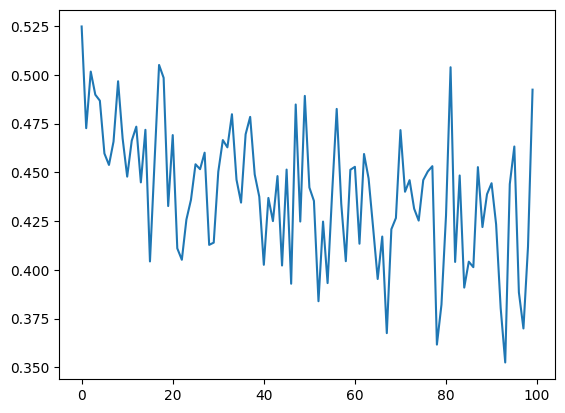

In [15]:
plt.plot(lossi)

In [16]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte)
    }[split]
    emb = C[x]
    hpreact = emb.view(emb.shape[0], -1) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.6783621311187744
val 2.7540502548217773


In [9]:
#Sampling
for _ in range(10):
    name = ""
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        hpreact = emb.view(emb.shape[0], -1) @ W1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        name += itos[ix]
        context = context[1:] + [ix]
    print(name)

SDUSÇAŞCBVJÇŞAŞŞHİGPEFLPSIGPPJÜJZGGOGRTIGNAUKOÖÇEKT
IYNTCMBI
J V
ÖIZÇBHTEŞÖİBFCCMNKPŞFĞIÇŞTGOİPYÇGSNDFAF
DMUĞJ
KRĞFVNÜNUJ
IERİYÖHCŞVÖKÇŞ
MMZMUKVDŞFBLFRÜPÖYMZ
VBNTOCAEYĞJTBLSF
FİBOBJCMSVŞG CFZPYÖĞDGYİSLFNBY 


In [10]:
#Class section

In [11]:
class Linear:  
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

###

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #training parameters
        self.gamma = torch.ones(dim) #bngain
        self.beta = torch.zeros(dim) #bnbias
        #running statics (untrainable)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
            
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps )
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

###

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [29]:
#Deeper network setup
n_embd = 10
n_hidden = 100

C = torch.randn((vocab_size, n_embd))

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]

for p in parameters:
    p.requires_grad = True


print(sum(p.nelement() for p in parameters))


50384


In [30]:
#new training loop with classes layout
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    #Mini-Batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
                       
    #Forward-Pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers: x = layer(x)
    loss = F.cross_entropy(x, Yb)

    #Backward pass
    for layer in layers: layer.out.retain_grad()
    for p in parameters: p.grad = None
    loss.backward()

    #Update parameters
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters: 
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0 or i == 0: print(f"{loss.item():.4f}")
    lossi.append(loss.log10().item())
    ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break #after_debug: would take out obviously to run full optimization

4.0477


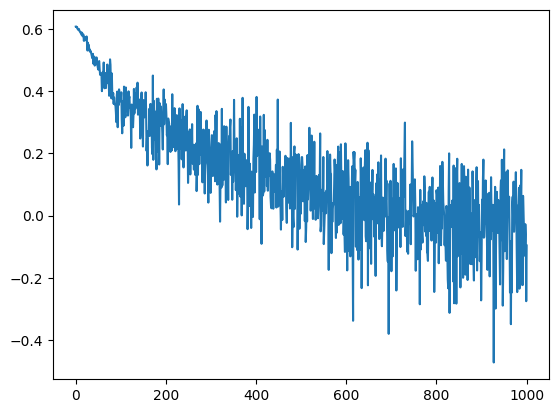

In [31]:
plt.plot(lossi)

In [32]:
#eval mode for split loss
for layer in layers:
    layer.training = False

#split loss
@torch.no_grad()

def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val" : (Xdev, Ydev),
        "test" : (Xte, Yte),
    }[split]

    emb = C[x]
    x = emb.view(emb.shape[0], -1)

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, y)

    print(split, loss.item())
    
split_loss("train")
split_loss("val")

    

train 0.8149252533912659
val 2.0455482006073


In [33]:
#sampling
for _ in range(20):
    name = ""
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        name += itos[ix]
        context = context [1:] + [ix]
    print(name)


['hammel']
['ıamaG']
['Hzt]a']
['yiLOehÇn']
['dullah']
e']
['li,']
['Um[]
['Sultan']
['Emin']
['ülit']
['YareHtn']
['Yaren']
['MufŞa']
['Sume']
['grÖf']
['Börck[iEcsğnur']
['Eren']
['Ayhan']
['Zeyna']


layer 2 (Tanh): mean 0.05, std 0.60, saturated: 1%
layer 5 (Tanh): mean 0.15, std 0.62, saturated: 2%
layer 8 (Tanh): mean 0.01, std 0.62, saturated: 1%
layer 11 (Tanh): mean 0.06, std 0.62, saturated: 0%
layer 14 (Tanh): mean 0.08, std 0.65, saturated: 1%


Text(0.5, 1.0, 'activation distribution')

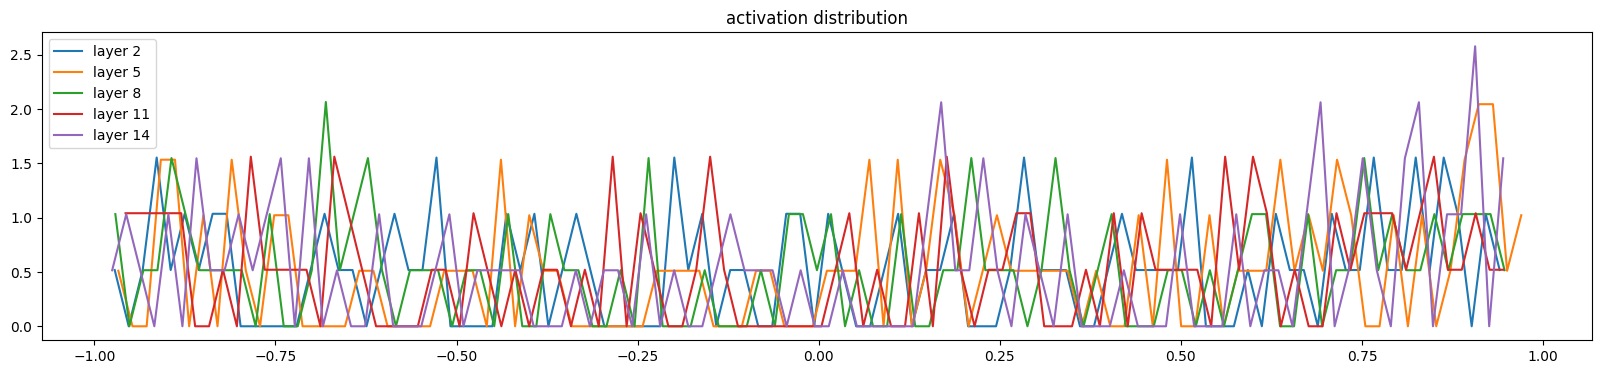

In [34]:
#activation distribution
plt.figure(figsize=(20,4))

legends = []

for i, layer in enumerate(layers):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f"layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturated: {(t.abs() > 0.97).float().mean()*100:.0f}%")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i}")
plt.legend(legends)
plt.title("activation distribution")

        
    

In [35]:
#gradian distribution
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f"layer {i} ({layer.__class__.__name__}): mean {t.mean():.6f}, std {t.std():.6f}")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i}")
plt.legend(legends)
plt.title("gradient distribution")

/var/folders/7h/zllxn_h17dx7gv3b32rn4jd00000gn/T/ipykernel_7515/1408533928.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:499.)
  t = layer.out.grad


AttributeError: 'NoneType' object has no attribute 'mean'

<Figure size 2000x400 with 0 Axes>

Text(0.5, 1.0, 'update to data ratio (log10)')

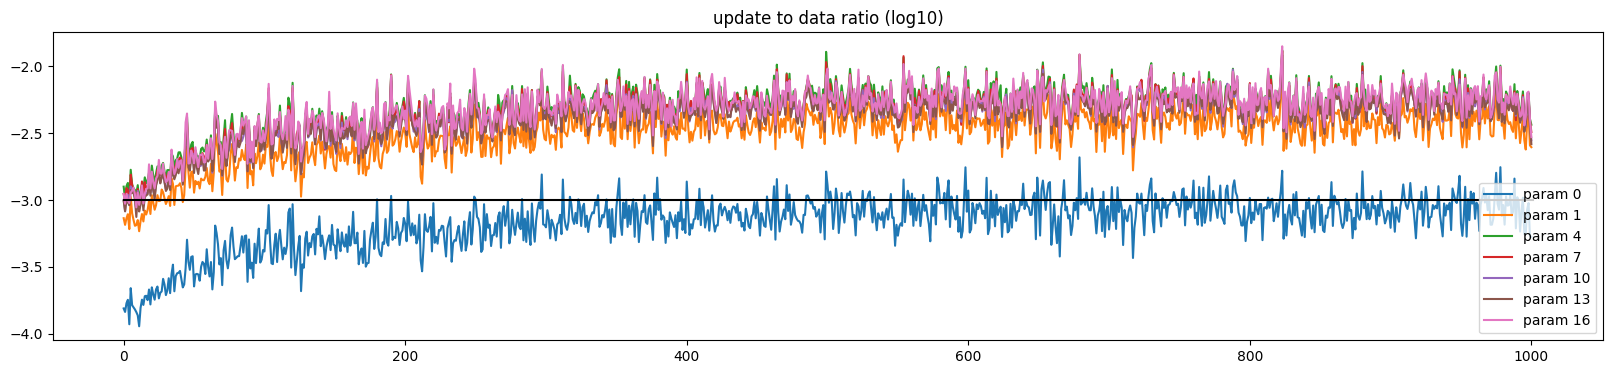

In [36]:
#Update/Data ratio
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f"param {i}")
plt.plot([0, len(ud)], [-3, -3], "k") #ideal line
plt.legend(legends)
plt.title("update to data ratio (log10)") 